Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4740.94it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


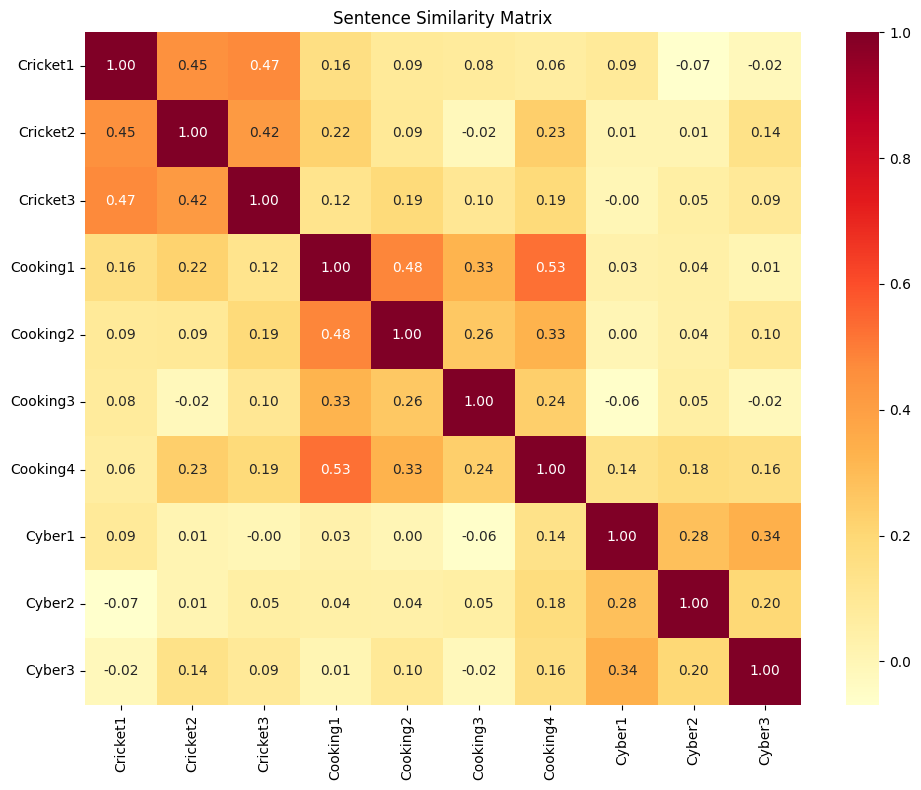

Query: The bowler took three wickets in one over

Similarity: 0.4942
Sentence: A skilled bowler can change the outcome of a match with precise deliveries.

Similarity: 0.4364
Sentence: Cricket is a sport played between two teams where each side takes turns batting and fielding.



In [2]:
# !pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sentences = [
    "Cricket is a sport played between two teams where each side takes turns batting and fielding.",
    "A skilled bowler can change the outcome of a match with precise deliveries.",
    "Fans often celebrate centuries and hat-tricks as major achievements in cricket matches.",
    "Cooking requires a balance of ingredients, timing, and technique to create delicious meals.",
    "Many people enjoy experimenting with spices to enhance the flavor of their dishes.",
    "Baking bread at home can be both relaxing and rewarding.",
    "Proper knife skills are essential for efficient and safe cooking.",
    "Cybersecurity focuses on protecting systems, networks, and data from digital attacks.",
    "Strong passwords and multi-factor authentication help prevent unauthorized access.",
    "Regular software updates are crucial to fix vulnerabilities and improve security."
]

# Selecting Transformer model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# generate embeddings
embeddings = model.encode(sentences)

# determining the similarities between the sentences
similarity_matrix = cosine_similarity(embeddings)

# Short labels for readability
labels = [
    "Cricket1", "Cricket2", "Cricket3",
    "Cooking1", "Cooking2", "Cooking3", "Cooking4",
    "Cyber1", "Cyber2", "Cyber3"
]

# plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix,
            annot=True,
            fmt='.2f',
            xticklabels=labels,
            yticklabels=labels,
            cmap='YlOrRd')
plt.title('Sentence Similarity Matrix')
plt.tight_layout()
plt.show()

query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 most similar
top_indices = np.argsort(similarities)[::-1][:2]

print(f"Query: {query}\n")
for idx in top_indices:
    print(f"Similarity: {similarities[idx]:.4f}")
    print(f"Sentence: {sentences[idx]}\n")